# Planetary PV versus topographic steering

This notebook tests whether tilt aligns with planetary PV gradients offshore but with topographic PV gradients over the shelf/slope. It reuses the established PV calculations in `seacofs_tilt_tools`; no PV formula is duplicated here.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(ANALYSIS_ROOT / "beta_effect_background_flow") not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT / "beta_effect_background_flow"))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")


Rows: 127,426; measured tilts: 105,621; eddies: 2,982


In [2]:
N2_CACHE = Path("/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/tilt_mechanisms/n2_eddy_day_v3_core.parquet")
n2 = pd.read_parquet(N2_CACHE)
data = mech.merge_one_to_one_or_many_to_one(df, n2)
for depth in (200, 500):
    data[f"N2_{depth}m_s2"] = data[f"N2_{depth}m_core_s2"]
latitude_col = "lat" if "lat" in data else "yc"
data = mech.add_eddy_stratification_categories(
    data, "N2_500m_s2", class_col="N2Class"
)
data = mech.add_eddy_stratification_categories(
    data, "N2_500m_s2", class_col="N2ClassLatitudeAdjusted", latitude_col=latitude_col
)
data = tilt.add_pv_gradient_terms(data, grid)
data = tilt.add_region_labels(data, grid)
data = mech.add_topographic_regimes(data, shelf_depth=2000.0, dominance_ratio=2.0)

for reference in ["PV_grad_plan_theta", "PV_grad_topo_theta", "PV_grad_theta"]:
    data[f"signed_{reference}_offset"] = mech.signed_angle_difference(data["TiltDir"], data[reference])

offsets = ["signed_PV_grad_plan_theta_offset", "signed_PV_grad_topo_theta_offset", "signed_PV_grad_theta_offset"]
display(mech.circular_offset_summary(data, offsets, group=("Cyc", "ShelfRegime", "PVRegime")))


,Cyc,ShelfRegime,PVRegime,metric,eddies,mean_offset_deg,resultant_length,median_abs_offset_deg
0,AE,off_shelf,mixed,signed_PV_grad_plan_theta_offset,996,-172.497365,0.280772,184.720250
1,AE,off_shelf,mixed,signed_PV_grad_topo_theta_offset,996,107.079958,0.033448,174.650350
2,AE,off_shelf,mixed,signed_PV_grad_theta_offset,996,-178.487914,0.202460,181.428656
3,AE,off_shelf,planetary,signed_PV_grad_plan_theta_offset,524,-175.561068,0.238133,183.091162
4,AE,off_shelf,planetary,signed_PV_grad_topo_theta_offset,524,64.788995,0.047434,166.295894
5,AE,off_shelf,planetary,signed_PV_grad_theta_offset,524,-175.791218,0.225309,182.640223
6,AE,off_shelf,topographic,signed_PV_grad_plan_theta_offset,1224,-161.856367,0.329452,192.569651
7,AE,off_shelf,topographic,signed_PV_grad_topo_theta_offset,1224,-62.110776,0.060111,193.112874
8,AE,off_shelf,topographic,signed_PV_grad_theta_offset,1224,-112.247984,0.062440,193.241773
9,AE,on_shelf,mixed,signed_PV_grad_plan_theta_offset,259,165.535739,0.396276,163.356028


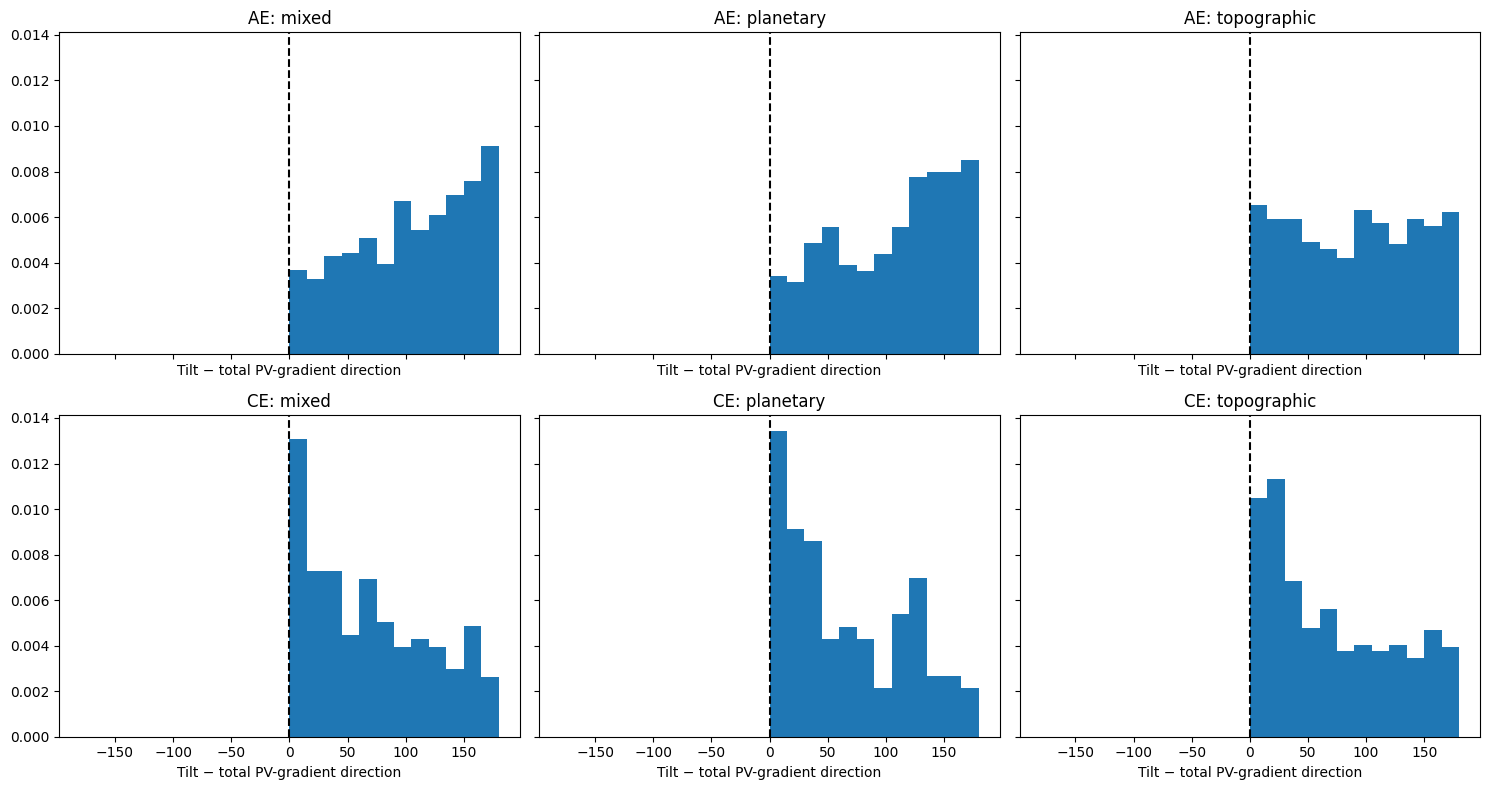

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, ((cyc, regime), part) in zip(axes.flat, data.groupby(["Cyc", "PVRegime"])):
    values = part.groupby("Eddy")["signed_PV_grad_theta_offset"].apply(tilt.circular_mean_deg_true_north)
    ax.hist(values, bins=np.arange(-180, 181, 15), density=True)
    ax.axvline(0, color="black", ls="--")
    ax.set(title=f"{cyc}: {regime}", xlabel="Tilt − total PV-gradient direction")
plt.tight_layout()


In [4]:
# Does topographic control strengthen with slope and eddy bottom contact?
data["slope_mag"] = np.hypot(data["dhdx"], data["dhdy"])
if "EddyDepth" in data:
    data["penetration_fraction"] = data["EddyDepth"].abs() / data["h"]
else:
    data["penetration_fraction"] = np.nan

summary = (data.groupby(["Cyc", "ShelfRegime", "PVRegime"])
           .agg(rows=("TiltDis", "size"), eddies=("Eddy", "nunique"),
                tilt_km=("TiltDis", "median"), slope=("slope_mag", "median"),
                topo_plan=("topo_plan_ratio_raw", "median"),
                abs_topo_offset=("signed_PV_grad_topo_theta_offset", lambda x: np.nanmedian(np.abs(x))))
           .reset_index())
display(summary)


,Cyc,ShelfRegime,PVRegime,rows,eddies,tilt_km,slope,topo_plan,abs_topo_offset
0,AE,off_shelf,mixed,18636,1071,16.056803,0.001756,1.148483,92.733454
1,AE,off_shelf,planetary,3958,593,14.232134,0.000615,0.347356,87.123351
2,AE,off_shelf,topographic,33489,1275,23.432326,0.007538,6.487890,87.534997
3,AE,on_shelf,mixed,3130,301,15.419444,0.002118,1.085974,87.733182
4,AE,on_shelf,planetary,974,178,11.773702,0.000790,0.331533,87.786325
5,AE,on_shelf,topographic,4765,311,20.541732,0.043869,30.543174,75.645610
6,CE,off_shelf,mixed,7638,884,13.989101,0.001124,1.346520,83.411431
7,CE,off_shelf,planetary,660,329,13.272843,0.000292,0.341617,91.126623
8,CE,off_shelf,topographic,40224,1315,18.193253,0.005999,7.897909,77.154684
9,CE,on_shelf,mixed,1567,321,11.041600,0.001082,1.335859,89.404577


In [5]:
# Primary directional test: categories use N2 residuals after removing each
# polarity's quadratic latitude trend, and every eddy receives equal weight.
direction_columns = {
    "Planetary PV": "signed_PV_grad_plan_theta_offset",
    "Topographic PV": "signed_PV_grad_topo_theta_offset",
}
eddy_direction = (data.groupby(["Cyc", "Eddy", "N2ClassLatitudeAdjusted"],
                               observed=True)[list(direction_columns.values())]
                  .agg(lambda values: tilt.circular_mean_deg_true_north(values.dropna()))
                  .reset_index())
# Circular means are returned in [0, 360); convert offsets back to [-180, 180).
for column in direction_columns.values():
    eddy_direction[column] = (eddy_direction[column] + 180.0) % 360.0 - 180.0
valid_counts = eddy_direction[list(direction_columns.values())].notna().sum()
print("Finite eddy-level directional offsets:")
display(valid_counts.to_frame("eddies"))
if (valid_counts < 100).any():
    raise ValueError("Too few finite eddy-level PV offsets; stop before plotting.")
direction_long = eddy_direction.melt(
    id_vars=["Cyc", "Eddy", "N2ClassLatitudeAdjusted"],
    value_vars=list(direction_columns.values()), var_name="offset_metric",
    value_name="offset_deg")
direction_long["reference"] = direction_long.offset_metric.map(
    {value: key for key, value in direction_columns.items()})
direction_long["alignment"] = np.cos(np.deg2rad(direction_long.offset_deg))
strat_direction = mech.circular_offset_summary(
    data, list(direction_columns.values()),
    group=("Cyc", "N2ClassLatitudeAdjusted"), eddy_equal=True)
strat_direction["reference"] = strat_direction.metric.map(
    {value: key for key, value in direction_columns.items()})
display(strat_direction.sort_values(["reference", "Cyc", "N2ClassLatitudeAdjusted"]))
from scipy.stats import spearmanr
category_score = {"Low": 0, "Medium": 1, "High": 2}
trend_rows = []
for (cyc, reference), part in direction_long.groupby(["Cyc", "reference"]):
    use = part.dropna(subset=["alignment", "N2ClassLatitudeAdjusted"]).copy()
    use["category_score"] = use.N2ClassLatitudeAdjusted.astype(str).map(category_score)
    rho, p = spearmanr(use.category_score, use.alignment)
    trend_rows.append({"Cyc": cyc, "reference": reference, "eddies": len(use),
                       "rho_category_alignment": rho, "p": p})
display(pd.DataFrame(trend_rows))


Finite eddy-level directional offsets:


,eddies
signed_PV_grad_plan_theta_offset,2953
signed_PV_grad_topo_theta_offset,2953


,Cyc,N2ClassLatitudeAdjusted,metric,eddies,mean_offset_deg,resultant_length,median_abs_offset_deg,reference
4,AE,High,signed_PV_grad_plan_theta_offset,473,-153.961994,0.343051,199.009152,Planetary PV
0,AE,Low,signed_PV_grad_plan_theta_offset,478,-163.519770,0.322377,194.827189,Planetary PV
2,AE,Medium,signed_PV_grad_plan_theta_offset,471,177.324244,0.348778,177.372575,Planetary PV
10,CE,High,signed_PV_grad_plan_theta_offset,511,-23.695657,0.223969,218.558118,Planetary PV
6,CE,Low,signed_PV_grad_plan_theta_offset,511,-25.249197,0.300492,235.501599,Planetary PV
8,CE,Medium,signed_PV_grad_plan_theta_offset,509,-27.119012,0.250555,229.271702,Planetary PV
5,AE,High,signed_PV_grad_topo_theta_offset,473,44.637815,0.048821,178.999763,Topographic PV
1,AE,Low,signed_PV_grad_topo_theta_offset,478,-25.985211,0.053710,174.547972,Topographic PV
3,AE,Medium,signed_PV_grad_topo_theta_offset,471,-61.910451,0.047683,189.454618,Topographic PV
11,CE,High,signed_PV_grad_topo_theta_offset,511,-14.739625,0.261632,197.928796,Topographic PV


,Cyc,reference,eddies,rho_category_alignment,p
0,AE,Planetary PV,1422,-0.004766,0.857484
1,AE,Topographic PV,1422,-0.008303,0.754399
2,CE,Planetary PV,1531,-0.051274,0.044865
3,CE,Topographic PV,1531,0.093398,0.000253


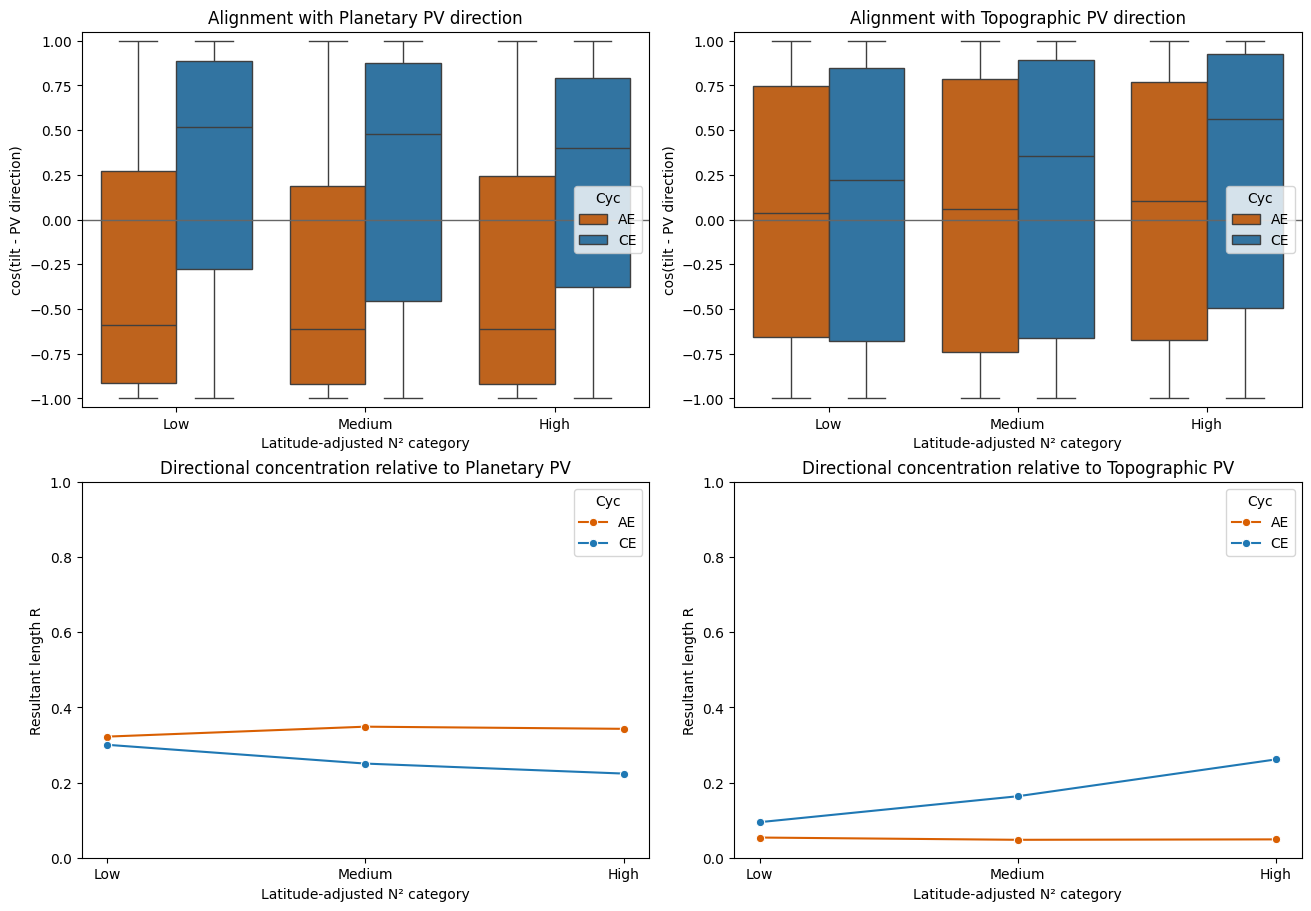

In [6]:
palette = {"AE": "#d95f02", "CE": "#1f78b4"}
order = ["Low", "Medium", "High"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for column, reference in enumerate(["Planetary PV", "Topographic PV"]):
    part = direction_long[direction_long.reference == reference]

    if part.alignment.isna().all():
        print(f"No data for {reference}")
        continue
    
    sns.boxplot(data=part, x="N2ClassLatitudeAdjusted", y="alignment", hue="Cyc",
                order=order, hue_order=["AE", "CE"], palette=palette,
                showfliers=False, ax=axes[0, column])
    axes[0, column].axhline(0, color="0.4", lw=1)
    axes[0, column].set(title=f"Alignment with {reference} direction",
                        xlabel="Latitude-adjusted N² category",
                        ylabel="cos(tilt - PV direction)")
    axes[0, column].set_ylim(-1.05, 1.05)
    summary_part = strat_direction[strat_direction.reference == reference]
    sns.lineplot(data=summary_part, x="N2ClassLatitudeAdjusted", y="resultant_length",
                 hue="Cyc", hue_order=["AE", "CE"], palette=palette, marker="o",
                 sort=False, ax=axes[1, column])
    axes[1, column].set(title=f"Directional concentration relative to {reference}",
                        xlabel="Latitude-adjusted N² category",
                        ylabel="Resultant length R", ylim=(0, 1))
plt.show()


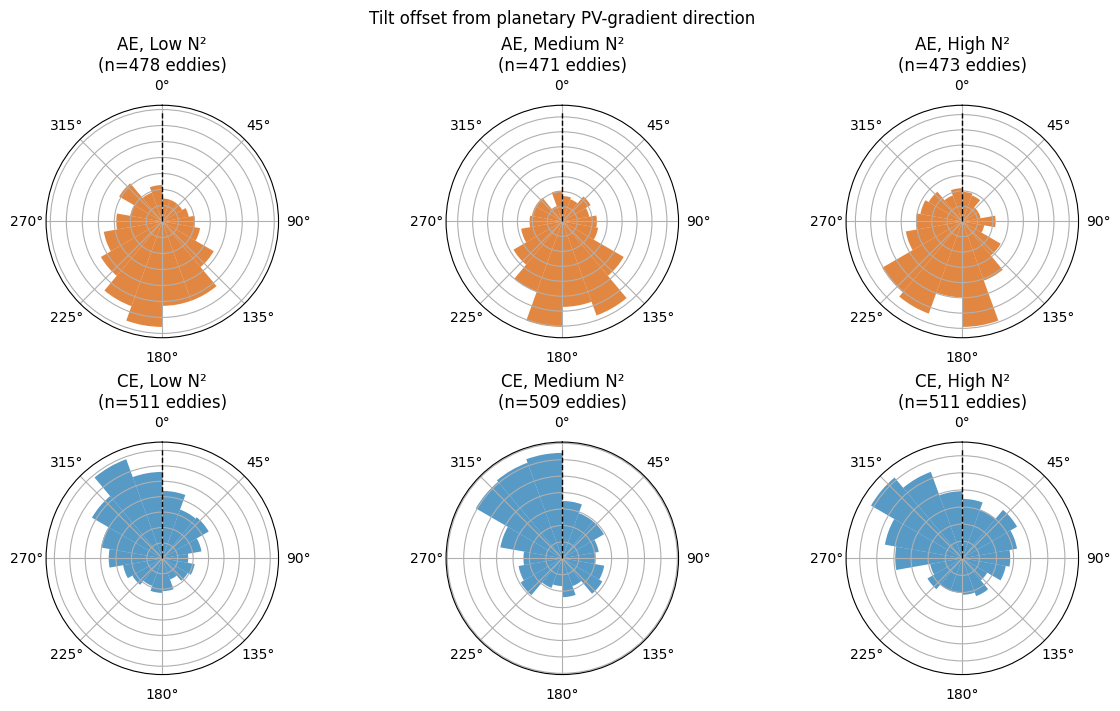

In [7]:
# Rose plots retain the full angular distribution hidden by a single alignment score.
fig, axes = plt.subplots(2, 3, figsize=(12, 7), subplot_kw={"projection": "polar"},
                         constrained_layout=True)
bins = np.deg2rad(np.arange(-180, 181, 20))
for row, cyc in enumerate(["AE", "CE"]):
    for column, category in enumerate(order):
        ax = axes[row, column]
        values = eddy_direction.loc[
            (eddy_direction.Cyc == cyc) &
            (eddy_direction.N2ClassLatitudeAdjusted == category),
            "signed_PV_grad_plan_theta_offset"].dropna()
        if values.empty:
            continue
        ax.hist(np.deg2rad(values), bins=bins, density=True, alpha=.75, color=palette[cyc])
        ax.plot([0, 0], [0, ax.get_ylim()[1]], "k--", lw=1)
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_yticklabels([])
        ax.set_title(f"{cyc}, {category} N²\n(n={len(values)} eddies)")
fig.suptitle("Tilt offset from planetary PV-gradient direction")
plt.show()


## Strong topographic-steering evidence would be

- tighter topographic-PV alignment as slope and bottom influence increase;
- stronger alignment in topographic-dominant than planetary-dominant regimes;
- a distinct on-shelf response that is not reproduced offshore;
- deep-centre propagation following isobaths more strongly than surface propagation (tested next).

For the stratified comparison, cosine alignment is +1 for parallel, 0 for perpendicular, and -1 for antiparallel tilt. Thus increasingly negative planetary-PV alignment can be meaningful for AEs, whose expected response is opposite the gradient, while increasingly positive alignment is meaningful for CEs. Resultant length `R` measures concentration only and must always be interpreted together with the mean offset and rose plots.
